## Questão 5

Um determinado circuito elétrico com tensão de entrada $v_i(t)$ e tensão de saída $v_o(t)$ é modelado através da seguinte equação diferencial ordinária:

$$
\frac{d^2v_o(t)}{dt^2}
+ 7\frac{dv_o(t)}{dt}
+ 10v_o(t)
=
\frac{dv_i(t)}{dt}
+ 6v_i(t)
$$

As condições iniciais para esse circuito são:

$$
v_o(0) = 6 \text{ V}
$$

e

$$
\frac{dv_o(0)}{dt} = -4 \text{ V/s}
$$

A entrada é dada por:

$$
x(t) = 6e^{-3t}u(t)
$$
---

a) Utilizando o método clássico, determine de forma analítica a saída do sistema $y(t)$ para todo $t$.

**1. Resposta Natural:**

A resposta natural é encontrada resolvendo a EDO homogênea:

$$
\frac{d^2 v_o(t)}{dt^2}
+
7\frac{dv_o(t)}{dt}
+
10v_o(t)
=
0
$$

Obtém-se a equação característica:

$$
Q(\lambda)=\lambda^2+7\lambda+10=0
$$

In [56]:
import sympy as sp
from IPython.display import display

# Variável simbólica
t = sp.symbols('t')

# Função
y = sp.Function('v0')

# EDO homogênea
ode_natural = sp.Eq(
    sp.diff(y(t), t, 2) +
    7*sp.diff(y(t), t) +
    10*y(t),
    0
)

# Solução geral
solucao_natural_geral = sp.dsolve(ode_natural)

print("Resposta Natural do Sistema (geral):")
display(solucao_natural_geral)

# Equação característica
lamb = sp.symbols('lambda')

eq_caracteristica = lamb**2 + 7*lamb + 10

raizes = sp.solve(eq_caracteristica, lamb)

print("Raízes da equação característica:")
print(f"λ₁ = {raizes[0]}")
print(f"λ₂ = {raizes[1]}")

Resposta Natural do Sistema (geral):


Eq(v0(t), (C1 + C2*exp(-3*t))*exp(-2*t))

Raízes da equação característica:
λ₁ = -5
λ₂ = -2


**3. Resposta Forçada:**

Conforme a **Tabela 2**, para entrada exponencial $e^{\xi t}$ onde $\xi \neq \lambda_i$ (raízes características), a forma da resposta forçada é $\beta e^{\xi t}$.


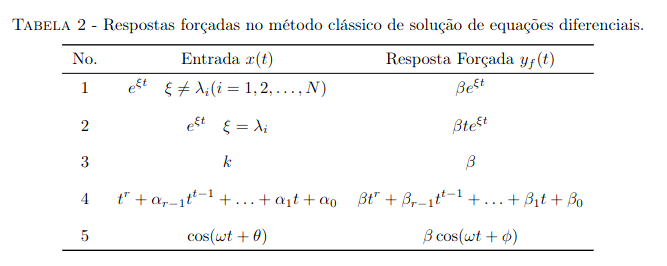


Para nossa entrada $x(t) = 6e^{-3t}$:
- $\xi = -3$ (não é raiz característica, pois $\alpha_1 = -5$ e $\alpha_2 = -2$)
- Assumimos forma: $y_f(t) = Ae^{-3t}$

In [57]:
# Variáveis simbólicas
t, A = sp.symbols('t A')

# Suposição da resposta forçada
y_f = A * sp.exp(-3*t)

# Derivadas
dy_f = sp.diff(y_f, t)
d2y_f = sp.diff(y_f, t, 2)

print("Suposição:")
display(sp.Eq(sp.Function('y_f')(t), y_f))

print("\nPrimeira derivada:")
display(sp.Eq(sp.Symbol("dy_f/dt"), dy_f))

print("\nSegunda derivada:")
display(sp.Eq(sp.Symbol("d²y_f/dt²"), d2y_f))

# Entrada
x = 6 * sp.exp(-3*t)

# Lado direito da EDO
rhs = sp.diff(x, t) + 6*x

print("\nLado direito da EDO:")
display(sp.Eq(sp.Symbol("dx/dt + 6x"), rhs))

# Equação forçada
eq_forcada = sp.Eq(
    d2y_f + 7*dy_f + 10*y_f,
    rhs
)

print("\nEquação a resolver:")
display(eq_forcada)

# Resolve para A
A_sol = sp.solve(eq_forcada, A)

print("\nValor encontrado para A:")
display(sp.Eq(A, A_sol[0]))

# Resposta forçada final
y_forced = A_sol[0] * sp.exp(-3*t)

print("\nResposta Forçada:")
display(sp.Eq(sp.Function('y_f')(t), y_forced))

Suposição:


Eq(y_f(t), A*exp(-3*t))


Primeira derivada:


Eq(dy_f/dt, -3*A*exp(-3*t))


Segunda derivada:


...

Eq(-2*A*exp(-3*t), 18*exp(-3*t))


Valor encontrado para A:


Eq(A, -9)


Resposta Forçada:


Eq(y_f(t), -9*exp(-3*t))

**3. Resposta Completa (Natural + Forçada)**

A resposta completa é a soma das respostas natural e forçada.

$$v_o(t) = C_1 e^{-2t} + C_2 e^{-5t} + -9e^{-3t}$$


**4. Aplicando as condições iniciais** 

Aplicando $v_o(0)=6$ e $v_o'(0)=-4$ para determinar $C_1$ e $C_2$.

In [58]:
# Variável simbólica
t = sp.symbols('t')

# Função
y = sp.Function('v0')

# Condições iniciais
condicoes_naturais = {
    y(0): 6,
    sp.diff(y(t), t).subs(t, 0): -4
}

# Entrada x(t)
x = 6 * sp.exp(-3*t)

print("Entrada do sistema:")
display(sp.Eq(sp.Function('x')(t), x))

# Lado direito da EDO
rhs = sp.diff(x, t) + 6*x

print("\nLado direito da EDO:")
display(sp.Eq(sp.Symbol("dx/dt + 6x"), rhs))

# EDO completa
ode_completa = sp.Eq(
    sp.diff(y(t), t, 2) +
    7*sp.diff(y(t), t) +
    10*y(t),
    rhs
)

print("\nEDO completa:")
display(ode_completa)

# Resolve a EDO com condições iniciais
solucao_completa = sp.dsolve(
    ode_completa,
    ics=condicoes_naturais
)

print("\nResposta Completa do Sistema:")
display(solucao_completa)

# Forma expandida
solucao_expandida = sp.expand(solucao_completa.rhs)

print("\nForma expandida:")
display(sp.Eq(y(t), solucao_expandida))

Entrada do sistema:


Eq(x(t), 6*exp(-3*t))


Lado direito da EDO:


Eq(dx/dt + 6x, 18*exp(-3*t))


EDO completa:


Eq(10*v0(t) + 7*Derivative(v0(t), t) + Derivative(v0(t), (t, 2)), 18*exp(-3*t))


Resposta Completa do Sistema:


Eq(v0(t), (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t))


Forma expandida:


Eq(v0(t), 44*exp(-2*t)/3 - 9*exp(-3*t) + exp(-5*t)/3)

---

b) Plote o sinal de saída para: $0 \leq t \leq 2$

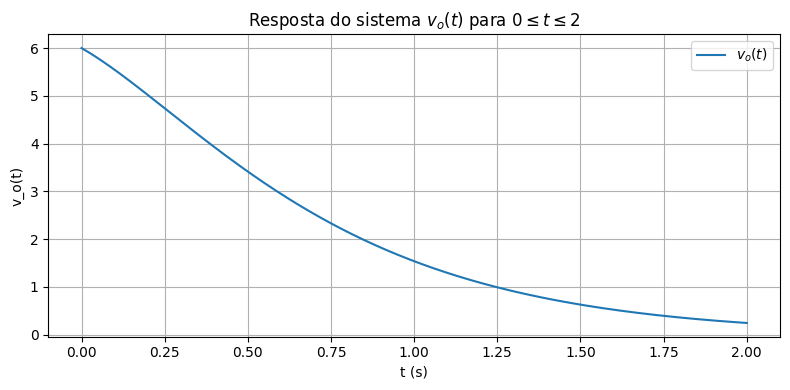

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify

try:
    vo_expr = solucao_expandida
except NameError:
    vo_expr = sp.expand(solucao_completa.rhs)

# Converte para função numérica
vo_num = lambdify(t, vo_expr, 'numpy')

# Pontos de tempo
ts = np.linspace(0, 2, 500)
ys = vo_num(ts)

# Plot
plt.figure(figsize=(8,4))
plt.plot(ts, ys, color='tab:blue', label=r'$v_o(t)$')
plt.xlabel('t (s)')
plt.ylabel('v_o(t)')
plt.title(r'Resposta do sistema $v_o(t)$ para $0 \leq t \leq 2$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---

c) Utilizando computação simbólica, determine a expressão de saída para esse circuito quando a entrada é a mesma da apresentada no item (a). Verifique e compare seu resultado com aquele obtido no item (a).



In [60]:
# Questão 5.c
# Resolução usando computação simbólica

# Variáveis simbólicas
t = sp.symbols('t')
vo = sp.Function('v_o')

# Entrada do sistema
vi = 6 * sp.exp(-3*t)

# Lado direito da EDO: dvi/dt + 6vi
lado_direito = sp.diff(vi, t) + 6*vi
# Equação diferencial completa
edo = sp.Eq(
    sp.diff(vo(t), t, 2) + 7*sp.diff(vo(t), t) + 10*vo(t),
    lado_direito
)
# Condições iniciais
condicoes_iniciais = {
    vo(0): 6,
    sp.diff(vo(t), t).subs(t, 0): -4
}

# Resolução simbólica da EDO
solucao_simbolica = sp.dsolve(edo, ics=condicoes_iniciais)
print("Solução simbólica:")
display(solucao_simbolica)

# Forma expandida
solucao_expandida_c = sp.expand(solucao_simbolica.rhs)

print("Forma expandida:")
display(solucao_expandida_c)

Solução simbólica:


Eq(v_o(t), (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t))

Forma expandida:


44*exp(-2*t)/3 - 9*exp(-3*t) + exp(-5*t)/3

Resposta: Esse resultado é igual ao obtido no item (a). Portanto, a resolução por computação simbólica confirma a solução encontrada pelo método clássico.